## Adversarial Attacks Series:

### Note 01: Fast Gradient Sign Method(FGSM)

#### Dataset: MNIST

 To create a CNN model you can read this article :

 Simple Convolutional Neural Network (CNN) for Dummies in PyTorch: A Step-by-Step Guide by Mayur Ingole
 
 link: https://medium.com/@myringoleMLGOD/simple-convolutional-neural-network-cnn-for-dummies-in-pytorch-a-step-by-step-guide-6f4109f6df80

In [ ]:
# 0. Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms


In [ ]:

# 1. ============ CNN ============
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)
        self.fc2 = nn.Linear(128, num_classes)
        self.fc1 = None
        self.flattened_size = None
    
    def reset_for_input_size(self, input_size):
        """Call this when input size changes"""
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_size, input_size)
            x = F.relu(self.conv1(dummy))
            x = F.max_pool2d(x, 2)
            x = F.relu(self.conv2(x))
            x = F.max_pool2d(x, 2)
            self.flattened_size = x.view(1, -1).size(1)
            self.fc1 = nn.Linear(self.flattened_size, 128)
            print(f"🔄 Reset model for input size {input_size}x{input_size} → flattened: {self.flattened_size}")
    
    def forward(self, x):
        if self.fc1 is None:
            raise ValueError("Call reset_for_input_size() first!")
        
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

#2. ============ LOAD DATA ============
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load a single image for testing
testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
image, label = testset[0]
image = image.unsqueeze(0)  # Add batch dimension: [1, 1, 28, 28]
print(f"Image shape: {image.shape}")
print(f"Label: {label}")

#3. ============ CREATE AND RESET MODEL ============
model = CNN()
model.reset_for_input_size(28)  # For MNIST 28x28 images

#4. ============ TRAINING SETUP ============
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#5. ============ FORWARD PASS ============
model.train()  # Set to training mode
output = model(image)
loss_value = criterion(output, torch.tensor([label]))
initial_pred = output.argmax().item()

print(f"\n📊 Initial forward pass:")
print(f"   Output shape: {output.shape}")
print(f"   Prediction: {initial_pred}")
print(f"   Loss: {loss_value.item():.4f}")

#6. ============  SAVE CHECKPOINT ============
epoch = 5  # epochs 5-10 

checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss_value.item(),  # Save as number, not tensor
    'flattened_size': model.flattened_size,
}

# Save checkpoint
torch.save(checkpoint, f'checkpoint_epoch_{epoch}.pth')
print(f"\n💾 Checkpoint saved: 'checkpoint_epoch_{epoch}.pth'")

#7. ============  LOAD CHECKPOINT (for resuming training) ============
# Create new model instance
loaded_model = CNN()
loaded_model.reset_for_input_size(28)  # Must reset first!

# Load checkpoint
checkpoint_path = f'checkpoint_epoch_{epoch}.pth'
checkpoint_loaded = torch.load(checkpoint_path)

loaded_model.load_state_dict(checkpoint_loaded['model_state_dict'])
optimizer.load_state_dict(checkpoint_loaded['optimizer_state_dict'])
start_epoch = checkpoint_loaded['epoch'] + 1
loaded_loss = checkpoint_loaded['loss']

print(f"\n📂 Checkpoint loaded:")
print(f"   Start epoch: {start_epoch}")
print(f"   Previous loss: {loaded_loss:.4f}")

#8. ============  VERIFY MODEL WORKS AFTER LOADING ============
loaded_model.eval()
with torch.no_grad():
    test_output = loaded_model(image)
    test_pred = test_output.argmax().item()
    print(f"\n✅ Model after loading:")
    print(f"   Prediction: {test_pred}")
    print(f"   True label: {label}")

#9. ============  SAMPLE INFERENCE ============
print("\n" + "="*50)
print("🔮 Running inference with loaded model:")
print("="*50)

loaded_model.eval()
with torch.no_grad():
    predictions = loaded_model(image)
    predicted_class = predictions.argmax().item()
    confidence = torch.softmax(predictions, dim=1)[0, predicted_class].item()
    
    print(f"Input shape: {image.shape}")
    print(f"Predicted class: {predicted_class}")
    print(f"True label: {label}")
    print(f"Confidence: {confidence:.4f}")
    print(f"Correct: {'✅ Yes' if predicted_class == label else '❌ No'}")

Image shape: torch.Size([1, 1, 28, 28])
Label: 7
🔄 Reset model for input size 28x28 → flattened: 800

📊 Initial forward pass:
   Output shape: torch.Size([1, 10])
   Prediction: 0
   Loss: 2.2688

💾 Checkpoint saved: 'checkpoint_epoch_5.pth'
🔄 Reset model for input size 28x28 → flattened: 800

📂 Checkpoint loaded:
   Start epoch: 6
   Previous loss: 2.2688

✅ Model after loading:
   Prediction: 0
   True label: 7

🔮 Running inference with loaded model:
Input shape: torch.Size([1, 1, 28, 28])
Predicted class: 0
True label: 7
Confidence: 0.1132
Correct: ❌ No


In [ ]:
from torch.utils.data import DataLoader

#10. ============ PREPARE DATA ============
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

#11. ============ CREATE MODEL ============
model = CNN()
model.reset_for_input_size(28)

#12. ============ TRAINING SETUP ============
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#13. ============ TRAINING LOOP WITH CHECKPOINTS ============
num_epochs = 10
start_epoch = 0

# Try to load existing checkpoint
try:
    checkpoint = torch.load('checkpoint_latest.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"✅ Resumed training from epoch {start_epoch}")
except FileNotFoundError:
    print("🆕 Starting fresh training")

print("\n" + "="*50)
print("🚀 Starting Training...")
print("="*50)

for epoch in range(start_epoch, num_epochs):
    model.train()
    running_loss = 0.0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch}, Batch {batch_idx}, Loss: {loss.item():.4f}")
    
    avg_loss = running_loss / len(train_loader)
    print(f"\n📊 Epoch {epoch} completed. Average Loss: {avg_loss:.4f}")
    
    # Save checkpoint after each epoch
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss,
        'flattened_size': model.flattened_size,
    }
    torch.save(checkpoint, 'checkpoint_latest.pth')
    torch.save(checkpoint, f'checkpoint_epoch_{epoch}.pth')
    print(f"💾 Checkpoint saved for epoch {epoch}")

print("\n✅ Training complete!")

#14. ============ EVALUATION ============
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\n📈 Test Accuracy: {100 * correct / total:.2f}%")

🔄 Reset model for input size 28x28 → flattened: 800
🆕 Starting fresh training

🚀 Starting Training...
Epoch 0, Batch 0, Loss: 2.2853
Epoch 0, Batch 100, Loss: 0.3119
Epoch 0, Batch 200, Loss: 0.1184
Epoch 0, Batch 300, Loss: 0.1373
Epoch 0, Batch 400, Loss: 0.0533
Epoch 0, Batch 500, Loss: 0.0572
Epoch 0, Batch 600, Loss: 0.1030
Epoch 0, Batch 700, Loss: 0.0888
Epoch 0, Batch 800, Loss: 0.1203
Epoch 0, Batch 900, Loss: 0.0324

📊 Epoch 0 completed. Average Loss: 0.1801
💾 Checkpoint saved for epoch 0
Epoch 1, Batch 0, Loss: 0.0880
Epoch 1, Batch 100, Loss: 0.0280
Epoch 1, Batch 200, Loss: 0.1127
Epoch 1, Batch 300, Loss: 0.0230
Epoch 1, Batch 400, Loss: 0.0473
Epoch 1, Batch 500, Loss: 0.0048
Epoch 1, Batch 600, Loss: 0.0934
Epoch 1, Batch 700, Loss: 0.1237
Epoch 1, Batch 800, Loss: 0.0037
Epoch 1, Batch 900, Loss: 0.0108

📊 Epoch 1 completed. Average Loss: 0.0515
💾 Checkpoint saved for epoch 1
Epoch 2, Batch 0, Loss: 0.0121
Epoch 2, Batch 100, Loss: 0.0281
Epoch 2, Batch 200, Loss: 0.01

In [ ]:

# 15. Define FGSM attack function
def fgsm_attack(image, epsilon, data_grad):
    # Collect the gradient sign
    sign_data_grad = data_grad.sign()
    # Create perturbed image
    perturbed_image = image + epsilon * sign_data_grad
    # Clamp to valid pixel range [0,1]
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image


In [ ]:
# 16. Select a correctly classified test image
image, label = testset[0]
image.requires_grad = True
output = model(image.unsqueeze(0))
initial_pred = output.argmax().item()
initial_confidence = torch.softmax(output, dim=1)[0, initial_pred].item()


In [ ]:
# 17. Compute loss and gradients
loss = nn.CrossEntropyLoss()(output, torch.tensor([label]))
model.zero_grad()
loss.backward()
data_grad = image.grad.data


In [ ]:

# 18. Generate adversarial example
epsilon = 0.05
perturbed_image = fgsm_attack(image, epsilon, data_grad)


In [ ]:
# 19. Evaluate on perturbed image
adv_output = model(perturbed_image.unsqueeze(0))
adv_pred = adv_output.argmax().item()
adv_confidence = torch.softmax(adv_output, dim=1)[0, adv_pred].item()


In [ ]:
# 20. Display results
print(f"Clean image: prediction {initial_pred}, confidence {initial_confidence:.4f}")
print(f"Adversarial image: prediction {adv_pred}, confidence {adv_confidence:.4f}")


Clean image: prediction 7, confidence 1.0000
Adversarial image: prediction 7, confidence 0.9916


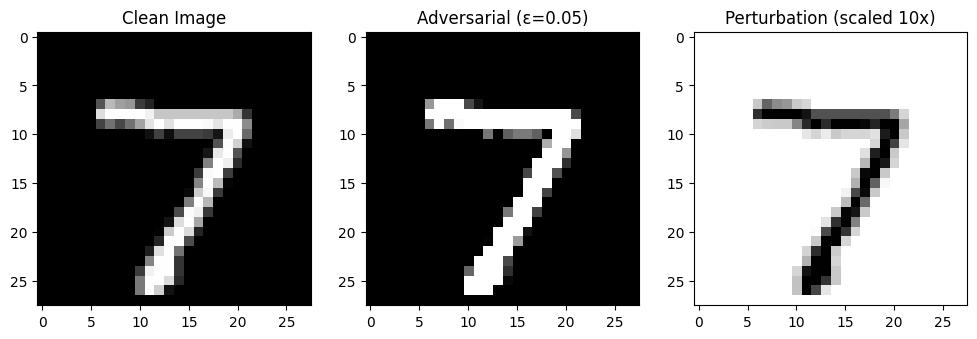

In [ ]:
# 21. Visualize: clean, adversarial, perturbation
perturbation = (perturbed_image - image).detach()
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# axes[0].imshow(image.squeeze(), cmap='gray')
axes[0].imshow(image.squeeze().detach().numpy(), cmap='gray')
axes[0].set_title("Clean Image")
axes[1].imshow(perturbed_image.squeeze().detach(), cmap='gray')
axes[1].set_title(f"Adversarial (ε={epsilon})")
axes[2].imshow(perturbation.squeeze() * 10, cmap='gray')  # scaled for visibility
axes[2].set_title("Perturbation (scaled 10x)")
plt.show()

In [ ]:
# 22. Print results
initial_pred = output.argmax().item()  
adv_pred = adv_output.argmax().item() 

# Now compare normally (works fine)
if initial_pred != adv_pred:
    print("✅ Attack succeeded!")

print(f"\n📊 Results:")
print(f"   Original prediction: {initial_pred}")
print(f"   Adversarial prediction: {adv_pred}")
print(f"   Success: {'✅ Attack succeeded!' if initial_pred != adv_pred else '❌ Attack failed'}")
print(f"   Epsilon used: {epsilon}")


📊 Results:
   Original prediction: 7
   Adversarial prediction: 7
   Success: ❌ Attack failed
   Epsilon used: 0.05


In [54]:
# Pseudocode — full implementation in the notebook
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    return torch.clamp(perturbed_image, 0, 1)

# Generate adversarial example
epsilon = 0.05
perturbed_image = fgsm_attack(image, epsilon, data_grad)

# Compare predictions
clean_pred = model(image.unsqueeze(0))
adv_pred = model(perturbed_image.unsqueeze(0))